# Critical Path for Data Quality, Consistency Alignment, and Pre-Clustering Feature Selection

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../EDAgroup5/data/sample_grouped_dataset-1.csv")

## **Systemic Null Value Resolution**

Define and execute an explicit, domain-justified rule for every missing value pattern identified in the panel dataset:

## Structural NULL handling

General rule applied to **every** imputed column: add a boolean
`_was_missing` flag **before** filling. 

In [18]:
imp_log = {}          
df_c = df.copy()

def impute(col, value, rule, add_flag=True, fill_label=None):
    n = int(df_c[col].isna().sum())
    if add_flag:
        df_c[col + "_was_missing"] = df_c[col].isna()
    df_c[col] = df_c[col].fillna(value)
    if fill_label is None:
        fill_label = value if np.isscalar(value) else "<vectorised>"
    imp_log[col] = {"rule": rule, "fill": fill_label,
                    "n_filled": n, "flag": f"{col}_was_missing" if add_flag else None}

### Group E — historical context

* **`*_avg_prev3m`** — user has no 3-month history yet. Neutral fill = the
  **current-month analogue** when one exists (best available estimate of the
  user's recent level), else the column median. A single `is_history_seed`
  flag marks these rows.
* **`*_delta_m`** — change vs. 3m average is genuinely *0* information when there
  is no baseline → fill **0**.
* **`spend_velocity_index_m`** — ratio-type index → fill **1.0** (neutral "no
  acceleration"), flagged.

In [19]:
LAG_ANALOGUE = {                       # prev3m feature  ->  current-month analogue
    "tx_count_avg_prev3m":           "tx_count_m",
    "tx_amount_avg_prev3m":          "tx_amount_avg_m",
    "oxxo_ratio_avg_prev3m":         "oxxo_tx_ratio_m",
    "cash_funding_ratio_avg_prev3m": "cash_funding_ratio_m",
    "ecommerce_ratio_avg_prev3m":    "ecommerce_tx_ratio_m",
}
df_c["is_history_seed"] = df_c["tx_count_avg_prev3m"].isna()   # single explanatory flag

for lag_col, cur_col in LAG_ANALOGUE.items():
    fill = df_c[cur_col].astype(float)
    fill = fill.fillna(fill.median())
    impute(lag_col, fill, f"first-3-months: fill with current-month analogue '{cur_col}', "
                          f"else median", add_flag=False,
           fill_label=f"current-month analogue '{cur_col}' (residual -> median)")

for d in ["tx_count_delta_m","tx_amount_avg_delta_m","oxxo_ratio_delta_m",
          "cash_funding_ratio_delta_m","ecommerce_ratio_delta_m"]:
    impute(d, 0.0, "no 3m baseline -> delta carries no signal -> 0", add_flag=False)

impute("spend_velocity_index_m", 1.0, "neutral 'no acceleration' index value")
print("Group E done. history-seed rows:", int(df_c['is_history_seed'].sum()))

Group E done. history-seed rows: 83025


## Group F — friction & recovery

* **`recovery_avg_min_m`** NULL ⇒ *there was nothing to recover from* (no decline,
  or no post-decline success). This is **not** a large latency — fill **0** and
  expose `had_decline_m` + `recovery_avg_min_m_was_missing` so the model can tell
  "recovered instantly" from "never needed to".
* **`top_rejection_reason_m`** NULL ⇒ no decline → explicit category **`"NONE"`**.
* **`oxxo_decline_ratio_m` / `same_merchant_retry_ratio_m`** — already 0-filled in
  source for no-decline users; leave as is.

In [20]:
df_c["had_decline_m"] = df_c["decline_count_m"].fillna(0).gt(0)
impute("recovery_avg_min_m", 0.0,
       "NULL = no decline or no post-decline success -> 0 min, keep flag + had_decline_m")

df_c["top_rejection_reason_m"] = (
    df_c["top_rejection_reason_m"].astype('category').cat.add_categories(["NONE"]).fillna("NONE"))
imp_log["top_rejection_reason_m"] = {"rule": "NULL = no declined tx -> category 'NONE'",
                                     "fill": "NONE", "n_filled": int(df["top_rejection_reason_m"].isna().sum()),
                                     "flag": None}
print(df_c["top_rejection_reason_m"].value_counts().head(6))

top_rejection_reason_m
ISUFFOPENTOBUY        222156
NONE                  209244
CARDBLOCKEDDECLINE     20081
CARDBLOCKEDFRAUD       13691
NOACTIONTAKEN          11510
INVALIDCVV2/CVC2        9159
Name: count, dtype: int64


# Pilar 2

## Zero-Activity vs. Ratio Alignment:
* **`oxxo_tx_ratio_m`** / **`ecommerce_tx_ratio_m`**: When a user has zero transaction activity (tx_count_m == 0), spending ratios render as undefined or zero-division anomalies. Force all channel ratios to 0.0 when transaction volume is zero, keeping the missingness flag consistent to explicitly mark inactive months.

In [21]:
zero_tx_mask = df_c['tx_count_m'] == 0
df_c.loc[zero_tx_mask, ['oxxo_tx_ratio_m', 'ecommerce_tx_ratio_m']] = 0.0

## Spend vs. Funding Discrepancies:
* **`spend_to_fund_ratio_m`**: When total monthly funding is zero (funding_amount_total_m == 0), calculating ratio metrics against total spend (tx_amount_sum_m) generates division-by-zero or infinite values. Force spend_to_fund_ratio_m to 0.0 (or a capped extreme upper limit if spend exists without new funding) and create a boolean flag is_zero_funding_m to capture this financial state.

In [22]:
df_c["is_zero_funding_m"] = df_c["funding_amount_total_m"] == 0
zero_funding_and_spend = df_c["is_zero_funding_m"] & (df_c["tx_amount_sum_m"].fillna(0) == 0)
df_c.loc[zero_funding_and_spend, "spend_to_fund_ratio_m"] = 0.0

## Delta Metric Consistency:
* **`oxxo_ratio_delta_m`** / **`tx_count_delta_m`**: Delta features must mathematically match the difference between current monthly values and historical averages (tx_count_m - tx_count_avg_prev3m). Recalculate and overwrite these columns directly from the reconciled source features to guarantee alignment across all panel records.

In [23]:
df_c["tx_count_delta_m"] = df_c["tx_count_m"] - df_c["tx_count_avg_prev3m"]
df_c["oxxo_ratio_delta_m"] = (df_c["oxxo_tx_ratio_m"] - df_c["oxxo_ratio_avg_prev3m"])

In [24]:
print(f"• Zero-activity rows aligned (ratios set to 0.0): {int(zero_tx_mask.sum())}")
print(f"• Zero-funding records flagged & neutralized: {int(df_c['is_zero_funding_m'].sum())}")
print(f"• {len(df_c)} total rows")

• Zero-activity rows aligned (ratios set to 0.0): 0
• Zero-funding records flagged & neutralized: 0
• 499993 total rows


## Remaining NULLs — recalculate where the formula is known, else impute

The NaN-rate of every column below is **flat across `tx_count_m` quartiles**, i.e.
the missingness is **MCAR** (injected noise), not a structural signal.

| column | status | fill |
|---|---|---|
| `spend_to_fund_ratio_m` | closed form | `tx_amount_sum_m / funding_amount_total_m` (denominator never 0) |
| `spending_dispersion_ratio_m` | closed form | `tx_amount_p90_m / tx_amount_p10_m` (`p10` never 0) |
| `tx_amount_stddev_m` | no raw tx amounts to rebuild it | `0` when `tx_count_m <= 1` (undefined), else column median |
| `intertx_avg_min_m` | not recomputable | `0` when `tx_count_m <= 1` (no interval), else median |
| `intertx_cv_m` | `= STDDEV(inter-tx) / intertx_avg_min_m`, numerator missing | `0` when `tx_count_m <= 1`, else median |
| `oxxo_amount_ratio_m` | no `SUM(oxxo amount)` column | no recalculation possible, flag mark 0
| `top_mcc_m` | categorical (excluded from numeric corr) | `"UNKNOWN"` |

Median (not `0`) is used for the MCAR gaps so the correlation matrix is not
distorted by an artificial spike at 0. Every touched column keeps a
`*_was_missing` flag.


In [26]:
df_c.isna().sum()
# Find all columns with missing values, check recalculations / imputations, and flags

userId                                     0
mes                                        0
gender                                     0
age_years                                  0
account_level                              0
account_age_days                           0
creation_flow                              0
tx_count_m                                 0
tx_amount_sum_m                            0
tx_amount_avg_m                            0
tx_amount_stddev_m                         0
tx_amount_max_m                            0
tx_amount_p90_m                            0
tx_amount_p10_m                            0
spending_dispersion_ratio_m                0
oxxo_tx_count_m                            0
oxxo_tx_ratio_m                            0
oxxo_amount_ratio_m                        0
fisico_non_oxxo_tx_ratio_m                 0
ecommerce_tx_ratio_m                       0
virtual_card_ratio_m                       0
intl_tx_ratio_m                            0
night_tx_r

In [25]:
# ── Resolve remaining NaNs (see table above) ─────────────────────────────────────
single_tx = df_c["tx_count_m"] <= 1

# 1. Closed-form recomputation (exact, no information invented) --------------------
impute("spend_to_fund_ratio_m",
       df_c["tx_amount_sum_m"] / df_c["funding_amount_total_m"],
       "closed form: tx_amount_sum_m / funding_amount_total_m",
       fill_label="tx_amount_sum_m / funding_amount_total_m")

impute("spending_dispersion_ratio_m",
       df_c["tx_amount_p90_m"] / df_c["tx_amount_p10_m"],
       "closed form: tx_amount_p90_m / tx_amount_p10_m",
       fill_label="tx_amount_p90_m / tx_amount_p10_m")

# 2. Not recomputable -> 0 when mathematically undefined (<=1 tx), else median -----
for col in ["tx_amount_stddev_m", "intertx_avg_min_m", "intertx_cv_m"]:
    n   = int(df_c[col].isna().sum())
    med = df_c[col].median()
    df_c[col + "_was_missing"] = df_c[col].isna()
    df_c[col] = df_c[col].mask(df_c[col].isna() & single_tx, 0.0).fillna(med)
    imp_log[col] = {"rule": "undefined for <=1 tx -> 0 ; MCAR gap -> median",
                    "fill": f"0 / median({med:.4g})", "n_filled": n,
                    "flag": f"{col}_was_missing"}

# 3. oxxo_amount_ratio_m: no SUM(oxxo amount) column ------------------------------
impute("oxxo_amount_ratio_m",
       df_c["oxxo_tx_ratio_m"].where(df_c["oxxo_tx_count_m"] > 0, 0.0),
       "no SUM(oxxo amount): 0 when oxxo_tx_count_m==0 else oxxo_tx_ratio_m proxy",
       fill_label="0 / oxxo_tx_ratio_m proxy")

# 4. top_mcc_m: categorical, outside the numeric analysis ------------------------
df_c["top_mcc_m"] = (df_c["top_mcc_m"].astype("category")
                     .cat.add_categories(["UNKNOWN"]).fillna("UNKNOWN"))
imp_log["top_mcc_m"] = {"rule": "MCAR gap in categorical -> 'UNKNOWN'", "fill": "UNKNOWN",
                        "n_filled": int(df["top_mcc_m"].isna().sum()), "flag": None}

_left = df_c.isna().sum()
print("remaining NaNs:", int(_left.sum()))
print(_left[_left > 0].to_string() if _left.sum() else "clean")

remaining NaNs: 0
clean


## Numeric correlation — dependency & redundancy on fully-valid data

All NaNs are resolved above, so the Spearman matrix below is computed on complete
cases. IDs, month key, `*_next_m` / `target_*` leakage columns, boolean flags and
constant columns are excluded. Pairs with `|rho| >= 0.90` are listed as redundancy
candidates (drop one per pair, or collapse into a single component, before
clustering).

54 numeric features in the correlation

14 redundant pairs (|Spearman rho| >= 0.90):
  +1.000   cashin_amount_m  <->  cashin_oxxo_amount_m
  +1.000   cash_funding_ratio_m  <->  oxxo_funding_ratio_m
  +1.000   cashin_count_m  <->  cashin_oxxo_count_m
  +0.996   oxxo_tx_ratio_m  <->  oxxo_amount_ratio_m
  +0.980   unique_merchants_m  <->  merchant_entropy_m
  +0.958   oxxo_tx_count_m  <->  oxxo_tx_ratio_m
  +0.957   cashin_amount_m  <->  oxxo_funding_ratio_m
  +0.957   cashin_amount_m  <->  cash_funding_ratio_m
  +0.957   cashin_oxxo_amount_m  <->  oxxo_funding_ratio_m
  +0.957   cashin_oxxo_amount_m  <->  cash_funding_ratio_m
  +0.952   oxxo_tx_count_m  <->  oxxo_amount_ratio_m
  +0.937   decline_count_m  <->  decline_ratio_m
  +0.916   tx_amount_avg_m  <->  tx_amount_p90_m
  +0.910   merchant_entropy_m  <->  mcc_entropy_m


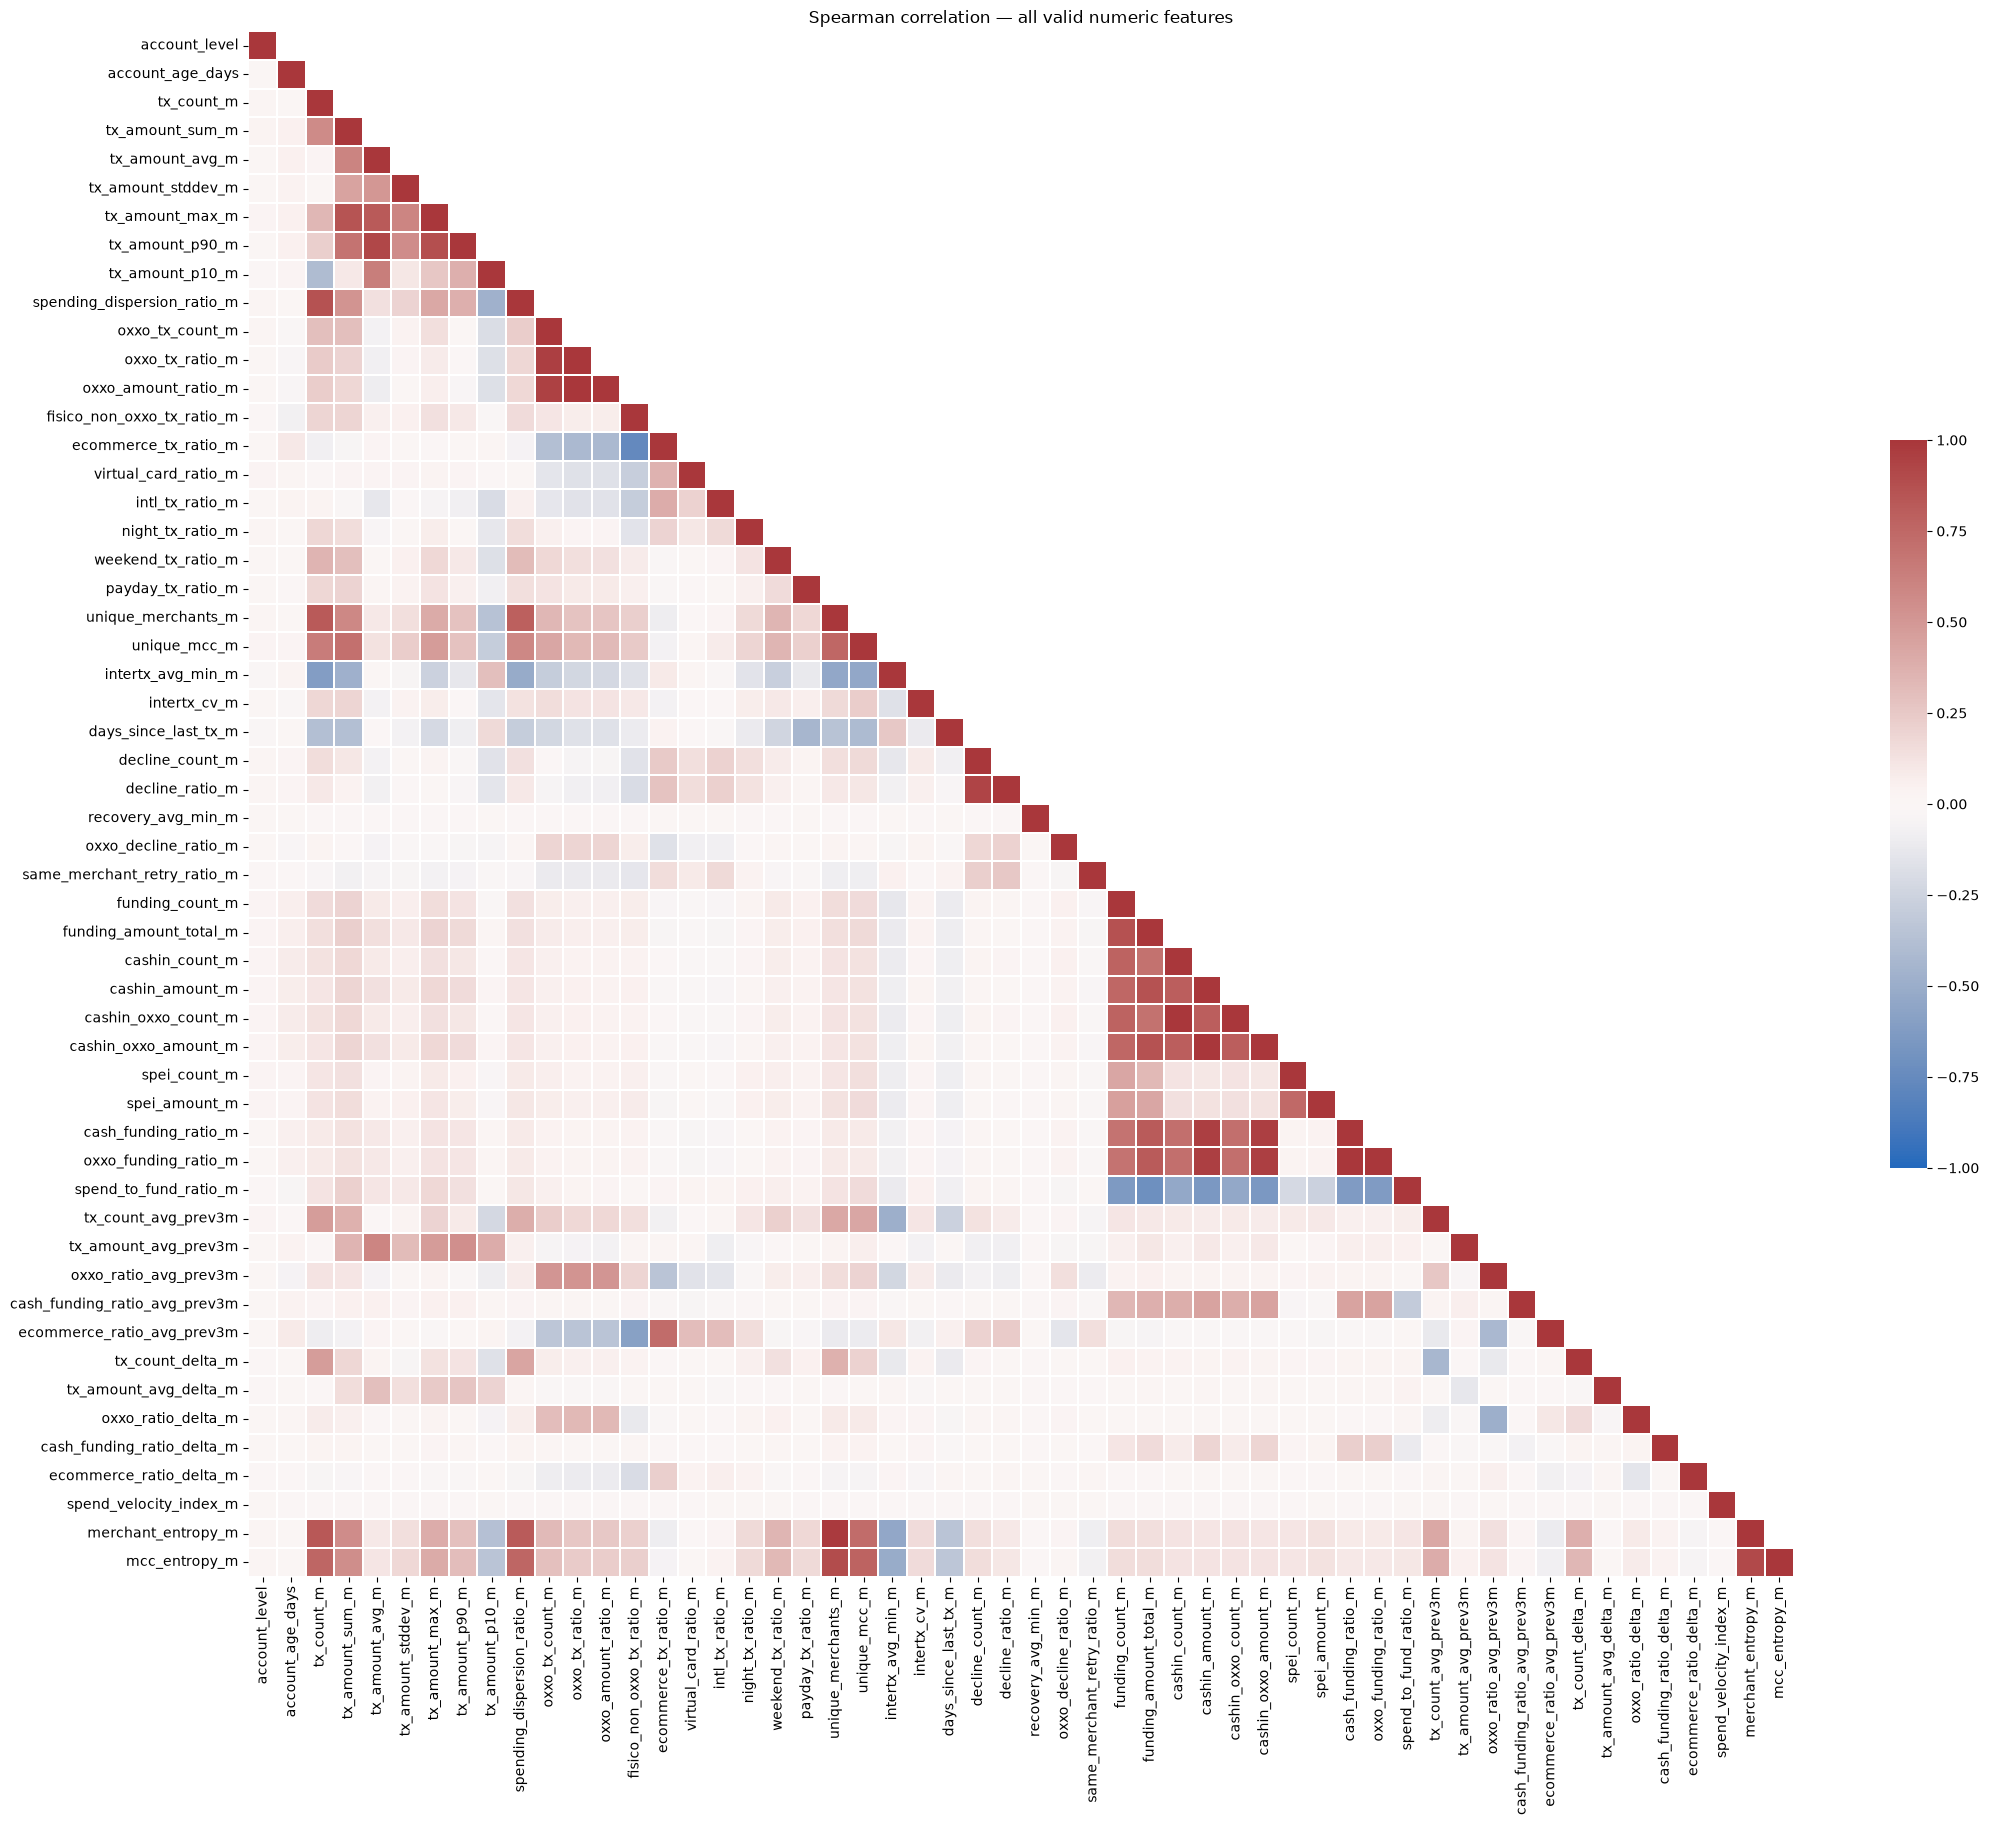

In [27]:
import itertools

assert df_c.isna().sum().sum() == 0, "resolve NaNs before correlating"

DROP_FROM_CORR = {
    "userId", "mes", "gender", "age_years",                                 # identifiers
    "has_next_month", "target_oxxo_migration", "target_ticket_growth",
    "oxxo_ratio_change_next_m", "ticket_change_next_m",  # future / leakage
}

num = df_c.select_dtypes("number")                       # bool flags excluded automatically
num = num.drop(columns=[c for c in DROP_FROM_CORR if c in num.columns])
num = num.loc[:, [c for c in num.columns if not c.endswith("_was_missing")]]
num = num.loc[:, num.nunique() > 1]                      # drop constants
print(f"{num.shape[1]} numeric features in the correlation")

corr = num.corr("spearman")

redundant = sorted(
    ((a, b, corr.loc[a, b])
     for a, b in itertools.combinations(corr.columns, 2)
     if abs(corr.loc[a, b]) >= 0.90),
    key=lambda t: -abs(t[2]),
)
print(f"\n{len(redundant)} redundant pairs (|Spearman rho| >= 0.90):")
for a, b, r in redundant:
    print(f"  {r:+.3f}   {a}  <->  {b}")

fig, ax = plt.subplots(figsize=(22, 20))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="vlag", center=0, vmin=-1, vmax=1, square=True,
            xticklabels=True, yticklabels=True, linewidths=.3,
            cbar_kws={"shrink": .4}, ax=ax)
ax.set_title("Spearman correlation — all valid numeric features")
plt.tight_layout(); plt.show()

In [13]:
pd.set_option('display.max_rows', None)

df_c.head().T

,0,1,2,3,4
userId,b1eef08b-4092-44ac-adf6-3148513fa02a,1f3d40fb-6213-425f-807b-374041eaf211,8cdd53a6-aec0-4986-a041-39d5213fd64f,af316b9f-9ac8-4e9d-84e1-a1c17500916c,7847e084-a428-4a92-a8c4-a81d070ac77c
mes,2026-03-27,2025-12-16,2026-01-29,2025-10-17,2025-11-24
gender,2,1,1,2,2
age_years,36,19,42,31,48
account_level,2,2,2,2,2
account_age_days,1134,365,725,872,1062
creation_flow,MOBILE,POS,MOBILE,POS,MOBILE
tx_count_m,1,1,1,1,1
tx_amount_sum_m,1.548987,0.730317,464.040964,0.02483,7.336411
tx_amount_avg_m,18.400762,40.117858,399.952809,4.564013,89.840695
